In [1]:
import numpy as np
from collections import Counter # Count garne values from a list or anything

In [2]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum(x2-x1)**2)

In [3]:
class KNN:
    def __init__(self, k =3):  # Init vaneko constructor create gareko
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        return [self._predict(x) for x in X]
    def _predict (self, x):
        distances = [euclidean_distance(x,x_train) for x_train in self.X_train] # Compute distances between x and all exapmles in distsnce
        k_indices = np.argsort(distances)[:self.k]  # get the indices of the k nearest neighbors
        k_neighbor_labels = [self.y_train[i] for i in k_indices]  # get labels for the k nearest neighbors

        # Majority Vote

        most_common = Counter (k_neighbor_labels). most_common(1)
        return most_common[0][0]
    def score(self, X,y):
        y_pred = self.predict(X)
        accuracy = np.sum(y_pred == y)/len(y)
        return accuracy




In [4]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Load Dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Initialize KNN
knn = KNN(3)
knn.fit(X_train, y_train)

# Calculate accuracy
accuracy = knn.score(X_test, y_test)
print(f"KNN Classification Accuracy:{accuracy}")

KNN Classification Accuracy:0.9


In [5]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy is:{accuracy}")

Accuracy is:1.0


In [15]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (important for distance-based algorithms)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Initialize KNN with Euclidean distance (default)
knn_euclidean = KNeighborsClassifier(metric='euclidean')
knn_euclidean.fit(X_train, y_train)

# Predict and evaluate
y_pred_euclidean = knn_euclidean.predict(X_test)
accuracy_euclidean = accuracy_score(y_test, y_pred_euclidean)

print(f"Euclidean Distance Accuracy: {accuracy_euclidean:.4f}")

Euclidean Distance Accuracy: 1.0000


In [17]:
# Initialize KNN with Manhattan distance

knn_manhattan = KNeighborsClassifier(metric='manhattan')
knn_manhattan.fit(X_train, y_train)

# Predict and evaluate
y_pred_manhattan = knn_manhattan.predict(X_test)
accuracy_manhattan = accuracy_score(y_test, y_pred_manhattan)

print(f"Manhattan Distance Accuracy: {accuracy_manhattan:.4f}")

Manhattan Distance Accuracy: 1.0000


In [7]:
from sklearn.neighbors import KNeighborsClassifier

X_train = [[1,2], [2,3], [3,4], [5,6], [7,8]]
y_train = ['A', 'A', 'A', 'B', 'B']

X_test = [[2, 3]]
y_test = ['A']

In [8]:
# Train KNN with K=1 (only looks at 1 nearest neighbor)

knn_k1 = KNeighborsClassifier(n_neighbors=1)
knn_k1.fit(X_train, y_train)

print(f"k=1 Prediction:{knn_k1.predict(X_test)[0]}")
print(f"Accuracy (K=1): {knn_k1.score(X_test, y_test)}")  

k=1 Prediction:A
Accuracy (K=1): 1.0


In [11]:
# Train KNN with K=50 (looks at 50 nearest neighbors)

knn_k5= KNeighborsClassifier(n_neighbors=5)
knn_k5.fit(X_train, y_train)

print(f"k=5 Prediction:{knn_k5.predict(X_test)[0]}")
print(f"Accuracy (K=5): {knn_k5.score(X_test, y_test)}") 
 

k=5 Prediction:A
Accuracy (K=5): 1.0


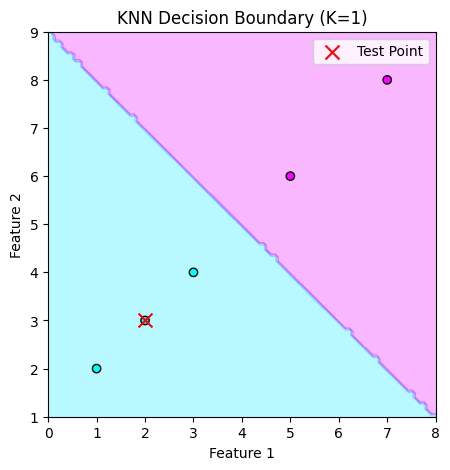

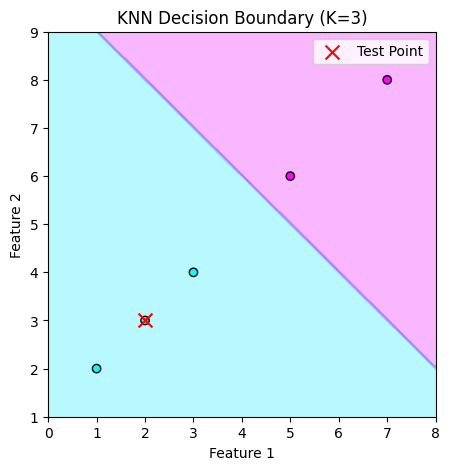

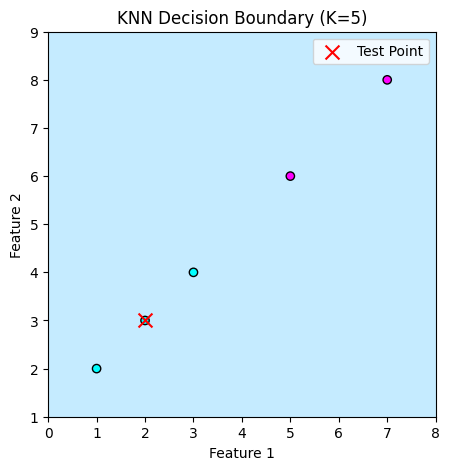

In [13]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt


X_train = np.array([[1,2], [2,3], [3,4], [5,6], [7,8]])
y_train = np.array([0, 0, 0, 1, 1])  

# Create mesh grid for visualization
x_min, x_max = 0, 8
y_min, y_max = 1, 9
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Plot for K=1, 3, 5
for k in [1, 3, 5]:
    plt.figure(figsize=(5, 5))
    
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predict on mesh grid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundaries
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='cool')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='cool', edgecolors='k')
    plt.title(f'KNN Decision Boundary (K={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    
    # Mark test point [2,3]
    plt.scatter([2], [3], c='red', marker='x', s=100, label='Test Point')
    plt.legend()
    
plt.show()